# Part 2 — College Scorecard Discovery

**Author(s):** Deva Rane  
**Creation date:** September 11, 2026  
**Data file:** `scorecard.csv` (local copy of the College Scorecard download)

### Assigned roles (POGIL)
If you are submitting with a group, replace these names with your team.

| Role | Person | Responsibility |
|------|--------|----------------|
| Manager / Coordinator | Deva Rane | Keep track of time and stay on task |
| Presenter / Spokesperson | Deva Rane | Report findings and ask questions |
| Recorder / Quality Control | Deva Rane | Review notes and help the team reach consensus |
| Reflector / Process Analyst | Deva Rane | Observe and comment on team dynamics |

This notebook is the discovery worksheet: we inspect the College Scorecard, compute summary facts, and write down what the numbers mean.


## 1. What is this data?

The U.S. Department of Education **College Scorecard** describes higher-education institutions: location, control (public / private), admission rate, SAT scores, tuition, completion, debt, and later earnings.

**Guiding questions**
1. What does one row represent?
2. Which columns are most useful for a student choosing a college?
3. What is missing or coded in a surprising way?
4. What claims can we support with this file?


## 2. Load a useful subset of columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# The full file has thousands of columns. Keep a readable subset.
cols = [
    'INSTNM', 'CITY', 'STABBR', 'CONTROL', 'ICLEVEL', 'PREDDEG',
    'ADM_RATE', 'SAT_AVG', 'UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT',
    'COSTT4_A', 'C150_4', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN',
    'PCTPELL', 'HBCU', 'INSTURL'
]

df = pd.read_csv('scorecard.csv', usecols=cols, low_memory=False)

# Some numeric fields arrive as strings such as PrivacySuppressed
for col in ['ADM_RATE', 'SAT_AVG', 'UGDS', 'TUITIONFEE_IN', 'TUITIONFEE_OUT',
            'COSTT4_A', 'C150_4', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'PCTPELL', 'HBCU']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

control_map = {1: 'Public', 2: 'Private nonprofit', 3: 'Private for-profit'}
level_map = {1: '4-year', 2: '2-year', 3: 'Less-than-2-year'}
df['control_name'] = df['CONTROL'].map(control_map)
df['level_name'] = df['ICLEVEL'].map(level_map)

print('Rows (institutions):', len(df))
print('Columns loaded:', df.shape[1])
df.head()

Rows (institutions): 6273
Columns loaded: 20


,INSTNM,CITY,STABBR,INSTURL,PREDDEG,CONTROL,HBCU,ADM_RATE,SAT_AVG,UGDS,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,PCTPELL,C150_4,GRAD_DEBT_MDN,MD_EARN_WNE_P10,ICLEVEL,control_name,level_name
0,Alabama A & M University,Normal,AL,www.aamu.edu/,3,1,1.0,0.5795,938.0,6124.0,27153.0,10024.0,18634.0,0.6298,0.2403,31000.0,40628.0,1,Public,4-year
1,University of Alabama at Birmingham,Birmingham,AL,https://www.uab.edu/,3,1,0.0,0.8818,1258.0,11635.0,28145.0,9098.0,22562.0,0.3402,0.6423,22300.0,54501.0,1,Public,4-year
2,Amridge University,Montgomery,AL,https://www.amridgeuniversity.edu/,3,2,0.0,NaN,NaN,241.0,NaN,7590.0,7590.0,0.7655,1.0000,32189.0,37621.0,1,Private nonprofit,4-year
3,University of Alabama in Huntsville,Huntsville,AL,www.uah.edu/,3,1,0.0,0.6857,1319.0,6591.0,27392.0,12132.0,26408.0,0.2464,0.6429,20705.0,61767.0,1,Public,4-year
4,Alabama State University,Montgomery,AL,www.alasu.edu/,3,1,1.0,0.9755,976.0,3477.0,23586.0,11248.0,19576.0,0.7134,0.3034,31000.0,34502.0,1,Public,4-year


### Recorder notes — first look

- Each **row** is one institution (a college, university, or other postsecondary school).
- `INSTNM` is the name. `STABBR` is the state. `CONTROL` is public / private nonprofit / private for-profit.
- `UGDS` is undergraduate enrollment. `ADM_RATE` is the admission rate (0 to 1).
- `TUITIONFEE_IN` is in-state tuition. `MD_EARN_WNE_P10` is median earnings about 10 years after entry.
- `GRAD_DEBT_MDN` is median debt among graduates.


## 3. Missing values and data quality

In [2]:
missing = df.isna().mean().sort_values(ascending=False)
print('Fraction of missing values by column:')
print(missing.round(3))
print()
print('Admission rate is missing for many schools (open-admission or not reported).')
print('SAT_AVG is missing even more often, because not every school uses SAT scores.')

Fraction of missing values by column:
SAT_AVG            0.835
ADM_RATE           0.696
C150_4             0.639
COSTT4_A           0.490
TUITIONFEE_IN      0.424
TUITIONFEE_OUT     0.424
GRAD_DEBT_MDN      0.238
MD_EARN_WNE_P10    0.183
PCTPELL            0.132
UGDS               0.127
HBCU               0.075
INSTURL            0.002
control_name       0.000
ICLEVEL            0.000
INSTNM             0.000
CITY               0.000
CONTROL            0.000
PREDDEG            0.000
STABBR             0.000
level_name         0.000
dtype: float64

Admission rate is missing for many schools (open-admission or not reported).
SAT_AVG is missing even more often, because not every school uses SAT scores.


## 4. How many schools, and where?

In [3]:
print('Number of institutions:', len(df))
print('Number of states/territories:', df['STABBR'].nunique())
print()
print('Schools by control type:')
print(df['control_name'].value_counts())
print()
print('Schools by level:')
print(df['level_name'].value_counts())
print()
print('Top 10 states by number of institutions:')
print(df['STABBR'].value_counts().head(10))

Number of institutions: 6273
Number of states/territories: 59

Schools by control type:
control_name
Private for-profit    2325
Public                2047
Private nonprofit     1901
Name: count, dtype: int64

Schools by level:
level_name
4-year              3010
Less-than-2-year    1712
2-year              1551
Name: count, dtype: int64

Top 10 states by number of institutions:
STABBR
CA    664
NY    417
TX    411
FL    377
PA    317
OH    279
IL    236
MI    172
NC    168
GA    162
Name: count, dtype: int64


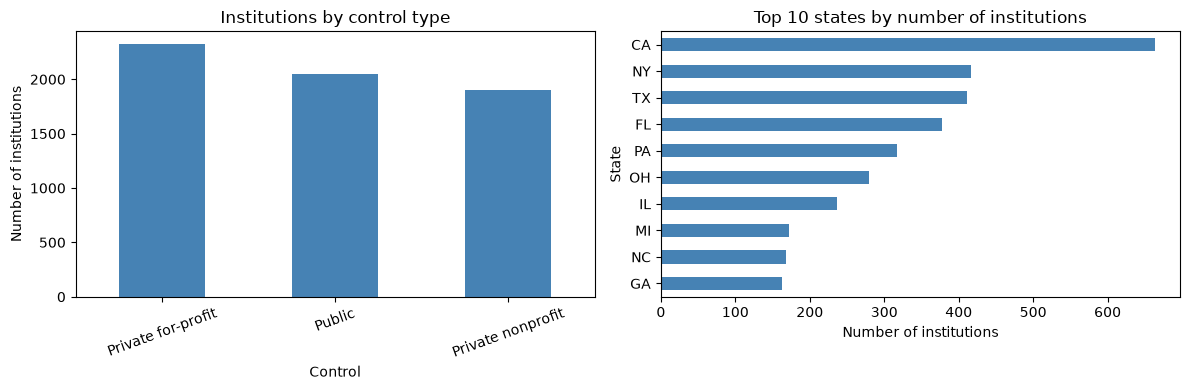

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['control_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Institutions by control type')
axes[0].set_xlabel('Control')
axes[0].set_ylabel('Number of institutions')
axes[0].tick_params(axis='x', rotation=20)

df['STABBR'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 states by number of institutions')
axes[1].set_xlabel('Number of institutions')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

## 5. Look up a school we recognize

In [5]:
# Search by a fragment of the name (change this to a school your group knows)
query = 'Harvard'
hits = df[df['INSTNM'].str.contains(query, case=False, na=False)]
hits[['INSTNM', 'CITY', 'STABBR', 'control_name', 'ADM_RATE', 'SAT_AVG',
      'UGDS', 'TUITIONFEE_IN', 'MD_EARN_WNE_P10']]

,INSTNM,CITY,STABBR,control_name,ADM_RATE,SAT_AVG,UGDS,TUITIONFEE_IN,MD_EARN_WNE_P10
1369,Harvard University,Cambridge,MA,Private nonprofit,0.0365,1553.0,7601.0,61676.0,101817.0


## 6. Selectivity (admission rate)

In [6]:
# Ignore 0% rates that are usually unusable / not a typical undergraduate college
four_year = df[(df['ICLEVEL'] == 1) & (df['UGDS'] >= 200) & (df['ADM_RATE'] > 0)]

print('4-year schools with reported admission rate and UGDS >= 200:', len(four_year))
print()
print('Admission rate summary:')
print(four_year['ADM_RATE'].describe())
print()
print('Most selective (lowest admission rate):')
print(
    four_year.nsmallest(10, 'ADM_RATE')
    [['INSTNM', 'STABBR', 'ADM_RATE', 'SAT_AVG', 'UGDS']]
    .to_string(index=False)
)

4-year schools with reported admission rate and UGDS >= 200: 1567

Admission rate summary:
count    1567.000000
mean        0.719994
std         0.225526
min         0.025700
25%         0.612300
50%         0.770900
75%         0.890200
max         1.000000
Name: ADM_RATE, dtype: float64

Most selective (lowest admission rate):
                                     INSTNM STABBR  ADM_RATE  SAT_AVG    UGDS
         California Institute of Technology     CA    0.0257      NaN   987.0
                         Minerva University     CA    0.0304      NaN   637.0
                        Stanford University     CA    0.0361   1553.0  7554.0
                         Harvard University     MA    0.0365   1553.0  7601.0
                            Yale University     CT    0.0387   1534.0  6758.0
Columbia University in the City of New York     NY    0.0399   1553.0  8973.0
                      University of Chicago     IL    0.0448   1554.0  7569.0
      Massachusetts Institute of Technology  

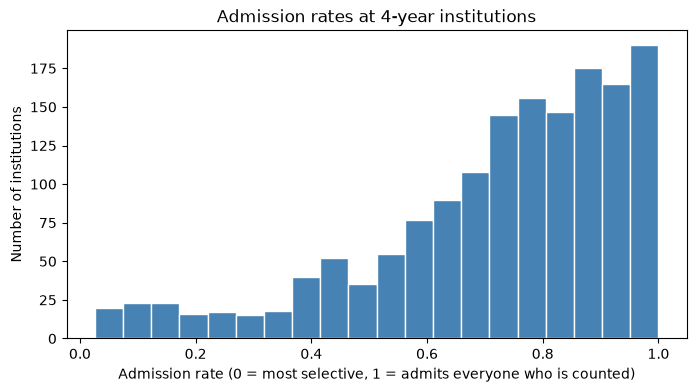

In [7]:
plt.figure(figsize=(8, 4))
four_year['ADM_RATE'].dropna().plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.title('Admission rates at 4-year institutions')
plt.xlabel('Admission rate (0 = most selective, 1 = admits everyone who is counted)')
plt.ylabel('Number of institutions')
plt.show()

### Consensus — selectivity

Most 4-year schools that report an admission rate are **not** extremely selective. The distribution sits well above 50%. A small group (Caltech, Stanford, Harvard, Yale, MIT, Princeton, and similar) has admission rates under 5%.


## 7. Price: in-state tuition

In [8]:
print('In-state tuition by control type:')
print(
    df.groupby('control_name')['TUITIONFEE_IN']
    .describe()[['count', 'mean', '50%', 'min', 'max']]
    .round(0)
)
print()
print('Highest in-state tuition:')
print(
    df.nlargest(8, 'TUITIONFEE_IN')
    [['INSTNM', 'STABBR', 'control_name', 'TUITIONFEE_IN']]
    .to_string(index=False)
)

In-state tuition by control type:
                     count     mean      50%  min      max
control_name                                              
Private for-profit   478.0  17066.0  16637.0  0.0  64500.0
Private nonprofit   1445.0  30959.0  29200.0  0.0  72097.0
Public              1689.0   6636.0   5507.0  0.0  25914.0

Highest in-state tuition:
                                     INSTNM STABBR      control_name  TUITIONFEE_IN
          University of Southern California     CA Private nonprofit        72097.0
Columbia University in the City of New York     NY Private nonprofit        71845.0
                             Kenyon College     OH Private nonprofit        71520.0
                           Brown University     RI Private nonprofit        71412.0
                             Vassar College     NY Private nonprofit        71030.0
              Franklin and Marshall College     PA Private nonprofit        70794.0
                            Trinity College     CT Priva

<Figure size 800x400 with 0 Axes>

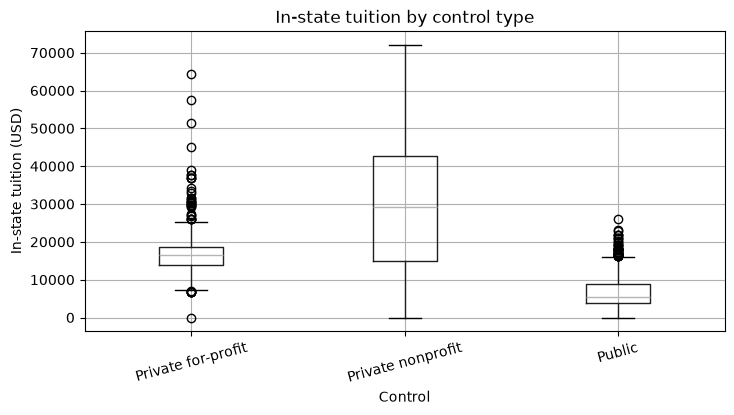

In [9]:
plt.figure(figsize=(8, 4))
df.boxplot(column='TUITIONFEE_IN', by='control_name', figsize=(8, 4))
plt.title('In-state tuition by control type')
plt.suptitle('')
plt.xlabel('Control')
plt.ylabel('In-state tuition (USD)')
plt.xticks(rotation=15)
plt.show()

### Consensus — cost

Public colleges have the lowest typical in-state tuition. Private nonprofit colleges have the highest list prices. For-profit tuition sits in between, with much smaller enrollments on average. Sticker price is not the same as what a student actually pays (net price / aid is a different Scorecard field).


## 8. Later earnings and student debt

In [10]:
print('Median earnings ~10 years after entry, by control type:')
print(df.groupby('control_name')['MD_EARN_WNE_P10'].median().round(0))
print()
print('Highest reported median earnings:')
print(
    df.nlargest(8, 'MD_EARN_WNE_P10')
    [['INSTNM', 'STABBR', 'control_name', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN']]
    .to_string(index=False)
)

Median earnings ~10 years after entry, by control type:
control_name
Private for-profit    30072.0
Private nonprofit     52214.0
Public                42362.0
Name: MD_EARN_WNE_P10, dtype: float64

Highest reported median earnings:
                                                 INSTNM STABBR      control_name  MD_EARN_WNE_P10  GRAD_DEBT_MDN
                  Massachusetts Institute of Technology     MA Private nonprofit         143372.0        14768.0
                              Samuel Merritt University     CA Private nonprofit         143238.0        20825.0
           Philadelphia College of Osteopathic Medicine     PA Private nonprofit         138767.0            NaN
                                    Harvey Mudd College     CA Private nonprofit         138687.0        25000.0
University of Health Sciences and Pharmacy in St. Louis     MO Private nonprofit         137047.0        17755.0
         Albany College of Pharmacy and Health Sciences     NY Private nonprofit         1

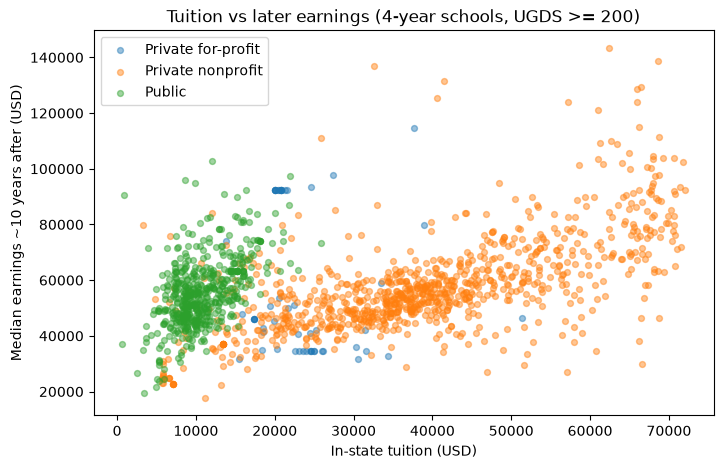

In [11]:
value = four_year.dropna(subset=['MD_EARN_WNE_P10', 'TUITIONFEE_IN'])
plt.figure(figsize=(8, 5))
for name, group in value.groupby('control_name'):
    plt.scatter(group['TUITIONFEE_IN'], group['MD_EARN_WNE_P10'], alpha=0.45, s=18, label=name)
plt.xlabel('In-state tuition (USD)')
plt.ylabel('Median earnings ~10 years after (USD)')
plt.title('Tuition vs later earnings (4-year schools, UGDS >= 200)')
plt.legend()
plt.show()

### Consensus — earnings

Higher list tuition does **not** automatically mean higher later earnings. Several specialized health and engineering schools rank near the top of earnings. Public colleges often show solid earnings at a much lower sticker price. For-profit schools in this file have lower typical earnings.


## 9. A 'best value' sketch (earnings relative to debt)

In [12]:
value = four_year.dropna(subset=['MD_EARN_WNE_P10', 'GRAD_DEBT_MDN']).copy()
value = value[value['GRAD_DEBT_MDN'] > 0]
value['earn_per_debt'] = value['MD_EARN_WNE_P10'] / value['GRAD_DEBT_MDN']

print('Highest median earnings per dollar of median graduate debt:')
print(
    value.nlargest(10, 'earn_per_debt')
    [['INSTNM', 'STABBR', 'control_name', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'earn_per_debt']]
    .round(2)
    .to_string(index=False)
)

Highest median earnings per dollar of median graduate debt:
                               INSTNM STABBR      control_name  MD_EARN_WNE_P10  GRAD_DEBT_MDN  earn_per_debt
                        Berea College     KY Private nonprofit          43150.0         3591.0          12.02
                 Princeton University     NJ Private nonprofit         110066.0        10320.0          10.67
                  Stanford University     CA Private nonprofit         124080.0        12000.0          10.34
United States Merchant Marine Academy     NY            Public          90610.0         8833.0          10.26
Massachusetts Institute of Technology     MA Private nonprofit         143372.0        14768.0           9.71
             Johns Hopkins University     MD Private nonprofit          87555.0        10250.0           8.54
                    Wellesley College     MA Private nonprofit          84803.0        10000.0           8.48
        Gods Bible School and College     OH Private nonprof

## 10. Group findings (what we would report out)

1. **Unit of analysis:** one row = one institution, not one student.
2. **Coverage:** about 6,000 institutions across U.S. states and territories. California, New York, and Texas have the most schools in the file.
3. **Missingness matters:** SAT averages and admission rates are missing for a large share of rows, so we cannot treat those columns as complete.
4. **Selectivity is the exception:** most reporting 4-year colleges admit well over half of applicants.
5. **Price and control are linked:** public in-state tuition is much lower than private nonprofit list tuition.
6. **Outcomes vary:** later earnings are highest at some STEM / health institutions; a high sticker price is not a guarantee of high earnings.
7. **Limitation:** these are institutional averages. They hide differences by major, and they are not a ranking of teaching quality.

### Reflector notes

The useful part of this activity was agreeing on *what a column actually measures* before making claims. The easy mistake is treating sticker tuition as cost, or treating a missing admission rate as "not selective."
